Ce notebook évalue les modèles entraînés sur l'ensemble de test (Alpes + Andes mélangés),
qui n'a jamais été utilisé pendant l'entraînement ou la sélection de modèle.

Modèles comparés :
1. U-Net Attention - Baseline sans augmentation, sans dropout/weight decay
2. U-Net Attention — sans augmentation, avec dropout + weight decay
3. U-Net Attention — avec augmentation, sans dropout/weight decay
4. U-Net Attention — avec augmentation + dropout + weight decay
5. DeepLabV3+ ResNet50 — modèle alternatif de comparaison 

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from glacier.data.data_fetching import repo_root
from glacier.model import (
    GlacierDataset,
    UNet,
    DiceBCELoss,
    compute_band_stats,
    discover_pairs,
    evaluate,
    show_predictions,
)

ROOT = repo_root()

DEVICE = torch.device("cpu")
print(f"Device : {DEVICE}")

Device : cpu


In [2]:
COMPOSITES_ROOT = ROOT / "data" / "sentinel2" / "composites"
MASKS_ROOT      = ROOT / "data" / "sentinel2" / "glims_masks"
CHECKPOINT_DIR  = ROOT / "data" / "checkpoints"
SPLITS_PATH     = CHECKPOINT_DIR / "splits.json"

# Paramètres
BATCH_SIZE = 4
PAD_TO     = 320
N_BANDS    = 5

# on recupere l'ensemble de test qu'on avait mis de coté

In [3]:
with open(SPLITS_PATH) as f:
    splits = json.load(f)

train_pairs  = [(Path(a), Path(b)) for a, b in splits["train"]]
test_pairs   = [(Path(a), Path(b)) for a, b in splits["test"]]
test_regions = splits["test_regions"]

print(f"Train : {len(train_pairs)} paires (Caucase)")
print(f"Test  : {len(test_pairs)} paires (Alpes + Andes mélangés)")
print(f"Détail test : {Counter(test_regions)}")

Train : 362 paires (Caucase)
Test  : 118 paires (Alpes + Andes mélangés)
Détail test : Counter({'alps': 65, 'andes': 53})


In [4]:
# Séparer les paires de test par région pour les métriques détaillées
test_pairs_alps  = [p for p, r in zip(test_pairs, test_regions) if r == "alps"]
test_pairs_andes = [p for p, r in zip(test_pairs, test_regions) if r == "andes"]

print(f"Test Alpes : {len(test_pairs_alps)} paires")
print(f"Test Andes : {len(test_pairs_andes)} paires")

Test Alpes : 65 paires
Test Andes : 53 paires


In [5]:
# On récupère mean/std depuis le checkpoint (calculés sur le train = Caucase)
# Cela évite de recalculer et garantit la cohérence avec l'entraînement
ckpt_ref = torch.load(CHECKPOINT_DIR / "best_unet.pt", map_location="cpu", weights_only=False)
mean = ckpt_ref["mean"]
std  = ckpt_ref["std"]
print("Mean par bande (B, G, R, NIR, SWIR16) :", mean)
print("Std  par bande (B, G, R, NIR, SWIR16) :", std)

Mean par bande (B, G, R, NIR, SWIR16) : [0.13889991 0.1671084  0.17913195 0.19808231 0.08576448]
Std  par bande (B, G, R, NIR, SWIR16) : [0.19173633 0.19432458 0.19876385 0.17478466 0.12561154]


In [6]:
# Datasets de test
ds_test_all   = GlacierDataset(test_pairs,       mean=mean, std=std, augment=False, pad_to=PAD_TO)
ds_test_alps  = GlacierDataset(test_pairs_alps,  mean=mean, std=std, augment=False, pad_to=PAD_TO)
ds_test_andes = GlacierDataset(test_pairs_andes, mean=mean, std=std, augment=False, pad_to=PAD_TO)

dl_test_all   = DataLoader(ds_test_all,   batch_size=BATCH_SIZE, shuffle=False)
dl_test_alps  = DataLoader(ds_test_alps,  batch_size=BATCH_SIZE, shuffle=False)
dl_test_andes = DataLoader(ds_test_andes, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test total : {len(ds_test_all)} images ({len(dl_test_all)} batchs)")
print(f"Test Alpes : {len(ds_test_alps)} images ({len(dl_test_alps)} batchs)")
print(f"Test Andes : {len(ds_test_andes)} images ({len(dl_test_andes)} batchs)")

Test total : 118 images (30 batchs)
Test Alpes : 65 images (17 batchs)
Test Andes : 53 images (14 batchs)


# Métriques d'évaluation 

On accumule les TP/FP/FN/TN sur l'ensemble du loader (pas de moyenne par batch)
pour des métriques robustes, surtout sur les petits datasets.

In [7]:
@torch.no_grad()
def compute_test_metrics(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    threshold: float = 0.5,
) -> dict[str, float]:
    """
    Calcule les métriques de segmentation pixel-wise.

    Accumule TP/FP/FN/TN sur tout le loader pour éviter
    les biais de moyennage par batch.
    """
    model.eval()
    total_tp = total_fp = total_fn = total_tn = 0

    for imgs, masks in loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        preds  = (torch.sigmoid(logits) > threshold).float()

        total_tp += ((preds == 1) & (masks == 1)).sum().item()
        total_fp += ((preds == 1) & (masks == 0)).sum().item()
        total_fn += ((preds == 0) & (masks == 1)).sum().item()
        total_tn += ((preds == 0) & (masks == 0)).sum().item()

    eps = 1e-8
    precision = total_tp / (total_tp + total_fp + eps)
    recall    = total_tp / (total_tp + total_fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = total_tp / (total_tp + total_fp + total_fn + eps)
    dice      = 2 * total_tp / (2 * total_tp + total_fp + total_fn + eps)
    accuracy  = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn + eps)

    return {
        "IoU":       round(iou, 4),
        "Dice":      round(dice, 4),
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1":        round(f1, 4),
        "Accuracy":  round(accuracy, 4),
        "TP": int(total_tp),
        "FP": int(total_fp),
        "FN": int(total_fn),
        "TN": int(total_tn),
    }

# Chargement et évaluation des modèles

In [8]:
def load_unet(checkpoint_path: Path, dropout: float = 0.0) -> nn.Module:
    """Charge un U-Net Attention depuis un checkpoint."""
    model = UNet(in_channels=N_BANDS, dropout=dropout, use_attention=True)
    state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state["model_state_dict"])
    model.to(DEVICE)
    model.eval()
    epoch = state.get("epoch", "?")
    val_iou = state.get("best_val_iou", state.get("val_iou", "?"))
    print(f"  Chargé : epoch={epoch}, val IoU={val_iou}")
    return model

In [9]:
experiments = {
    "U-Net: no aug, no dropout/wd": {
        "path": CHECKPOINT_DIR / "best_unet_baseline.pt",
        "dropout": 0.0,
    },
    "U-Net: no aug, dropout+wd": {
        "path": CHECKPOINT_DIR / "best_unet_wd_do.pt",
        "dropout": 0.3,
    },
    "U-Net: aug, no dropout/wd": {
        "path": CHECKPOINT_DIR / "best_unet_augmentation.pt",
        "dropout": 0.0,
    },
    "U-Net: aug + dropout + wd": {
        "path": CHECKPOINT_DIR / "best_unet_augmentation_wd_do.pt",
        "dropout": 0.3,
    },
}

# Vérifier quels checkpoints existent
for name, cfg in experiments.items():
    exists = cfg["path"].exists()
    print(f"  {'exists' if exists else 'does not exist'} {name} → {cfg['path'].name}")

  exists U-Net: no aug, no dropout/wd → best_unet_baseline.pt
  exists U-Net: no aug, dropout+wd → best_unet_wd_do.pt
  exists U-Net: aug, no dropout/wd → best_unet_augmentation.pt
  exists U-Net: aug + dropout + wd → best_unet_augmentation_wd_do.pt


In [10]:
# Évaluation de chaque expérience
results = []

for name, cfg in experiments.items():
    if not cfg["path"].exists():
        print(f"Checkpoint manquant : {name}, on skip.")
        continue

    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")

    model = load_unet(cfg["path"], dropout=cfg["dropout"])

    for region_name, loader in [
        ("Alpes",  dl_test_alps),
        ("Andes",  dl_test_andes),
        ("Global", dl_test_all),
    ]:
        metrics = compute_test_metrics(model, loader, DEVICE)
        metrics["Modèle"] = name
        metrics["Région"] = region_name
        results.append(metrics)
        print(
            f"  {region_name:8s} │ IoU {metrics['IoU']:.4f} │ Dice {metrics['Dice']:.4f} │ "
            f"P {metrics['Precision']:.4f} │ R {metrics['Recall']:.4f} │ "
            f"F1 {metrics['F1']:.4f} │ Acc {metrics['Accuracy']:.4f}"
        )

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


  U-Net: no aug, no dropout/wd
  Chargé : epoch=29, val IoU=0.7898294248823392
  Alpes    │ IoU 0.8143 │ Dice 0.8976 │ P 0.9396 │ R 0.8592 │ F1 0.8976 │ Acc 0.9291
  Andes    │ IoU 0.8195 │ Dice 0.9008 │ P 0.8868 │ R 0.9153 │ F1 0.9008 │ Acc 0.9027
  Global   │ IoU 0.8171 │ Dice 0.8993 │ P 0.9105 │ R 0.8885 │ F1 0.8993 │ Acc 0.9172

  U-Net: no aug, dropout+wd
  Chargé : epoch=52, val IoU=0.7888649005000874
  Alpes    │ IoU 0.8146 │ Dice 0.8978 │ P 0.9378 │ R 0.8611 │ F1 0.8978 │ Acc 0.9291
  Andes    │ IoU 0.8139 │ Dice 0.8974 │ P 0.9038 │ R 0.8911 │ F1 0.8974 │ Acc 0.9016
  Global   │ IoU 0.8142 │ Dice 0.8976 │ P 0.9195 │ R 0.8767 │ F1 0.8976 │ Acc 0.9168

  U-Net: aug, no dropout/wd
  Chargé : epoch=67, val IoU=0.7964417833392903
  Alpes    │ IoU 0.8193 │ Dice 0.9007 │ P 0.9420 │ R 0.8628 │ F1 0.9007 │ Acc 0.9312
  Andes    │ IoU 0.8285 │ Dice 0.9062 │ P 0.9065 │ R 0.9058 │ F1 0.9062 │ Acc 0.9095
  Global   │ IoU 0.8242 │ Dice 0.9036 │ P 0.9228 │ R 0.8852 │ F1 0.9036 │ Acc 0.9214



In [11]:
# repris de deeplabv3 (on devrait le mettre dans un fichier python et l'importer dnas les deux notebooks)

from torchvision.models.segmentation import deeplabv3_resnet50

def build_deeplabv3(in_channels: int = 5, pretrained_backbone: bool = True) -> nn.Module:
    model = deeplabv3_resnet50(
        weights="DEFAULT" if pretrained_backbone else None,
        num_classes=21,
    )
    old_conv = model.backbone.conv1
    new_conv = nn.Conv2d(
        in_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        mean_w = old_conv.weight.mean(dim=1, keepdim=True)
        for i in range(3, in_channels):
            new_conv.weight[:, i : i + 1] = mean_w
    model.backbone.conv1 = new_conv
    model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    if hasattr(model, "aux_classifier") and model.aux_classifier is not None:
        model.aux_classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    return model

class DeepLabV3Wrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
    def forward(self, x):
        out = self.base_model(x)["out"]
        if out.shape[2:] != x.shape[2:]:
            out = nn.functional.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)
        return out

In [12]:
DEEPLABV3_CKPT = CHECKPOINT_DIR / "best_deeplabv3.pt"

base = build_deeplabv3(in_channels=N_BANDS, pretrained_backbone=False)
state = torch.load(DEEPLABV3_CKPT, map_location=DEVICE, weights_only=False)
base.load_state_dict(state["model_state_dict"], strict=False)
model_dlv3 = DeepLabV3Wrapper(base).to(DEVICE)
model_dlv3.eval()

print(f"Checkpoint chargé (epoch {state['epoch']}, val IoU {state['val_iou']:.4f})")

print(f"\n{'='*65}")
print(f"  DeepLabV3+ (ResNet50)")
print(f"{'='*65}")

for region_name, loader in [
    ("Alpes",  dl_test_alps),
    ("Andes",  dl_test_andes),
    ("Global", dl_test_all),
]:
    metrics = compute_test_metrics(model_dlv3, loader, DEVICE)
    metrics["Modèle"] = "DeepLabV3+"
    metrics["Région"] = region_name
    results.append(metrics)
    print(
        f"  {region_name:8s} │ IoU {metrics['IoU']:.4f} │ Dice {metrics['Dice']:.4f} │ "
        f"P {metrics['Precision']:.4f} │ R {metrics['Recall']:.4f} │ "
        f"F1 {metrics['F1']:.4f} │ Acc {metrics['Accuracy']:.4f}"
    )

del model_dlv3, base

Checkpoint chargé (epoch 26, val IoU 0.7975)

  DeepLabV3+ (ResNet50)
  Alpes    │ IoU 0.8118 │ Dice 0.8961 │ P 0.9326 │ R 0.8624 │ F1 0.8961 │ Acc 0.9276
  Andes    │ IoU 0.8138 │ Dice 0.8973 │ P 0.9199 │ R 0.8758 │ F1 0.8973 │ Acc 0.9033
  Global   │ IoU 0.8128 │ Dice 0.8967 │ P 0.9259 │ R 0.8694 │ F1 0.8967 │ Acc 0.9167


In [13]:
if results:
    df = pd.DataFrame(results)
    cols = ["Modèle", "Région", "IoU", "Dice", "Precision", "Recall", "F1", "Accuracy"]
    display(
        df[cols]
        .style
        .format({c: "{:.4f}" for c in cols[2:]})
        .highlight_max(subset=["IoU", "Dice", "F1"], color="#d4edda", axis=0)
    )
else:
    print("Aucun résultat — vérifier que les checkpoints sont présents.")

,Modèle,Région,IoU,Dice,Precision,Recall,F1,Accuracy
0,"U-Net: no aug, no dropout/wd",Alpes,0.8143,0.8976,0.9396,0.8592,0.8976,0.9291
1,"U-Net: no aug, no dropout/wd",Andes,0.8195,0.9008,0.8868,0.9153,0.9008,0.9027
2,"U-Net: no aug, no dropout/wd",Global,0.8171,0.8993,0.9105,0.8885,0.8993,0.9172
3,"U-Net: no aug, dropout+wd",Alpes,0.8146,0.8978,0.9378,0.8611,0.8978,0.9291
4,"U-Net: no aug, dropout+wd",Andes,0.8139,0.8974,0.9038,0.8911,0.8974,0.9016
5,"U-Net: no aug, dropout+wd",Global,0.8142,0.8976,0.9195,0.8767,0.8976,0.9168
6,"U-Net: aug, no dropout/wd",Alpes,0.8193,0.9007,0.9420,0.8628,0.9007,0.9312
7,"U-Net: aug, no dropout/wd",Andes,0.8285,0.9062,0.9065,0.9058,0.9062,0.9095
8,"U-Net: aug, no dropout/wd",Global,0.8242,0.9036,0.9228,0.8852,0.9036,0.9214
9,U-Net: aug + dropout + wd,Alpes,0.8198,0.9010,0.9331,0.8709,0.9010,0.9307


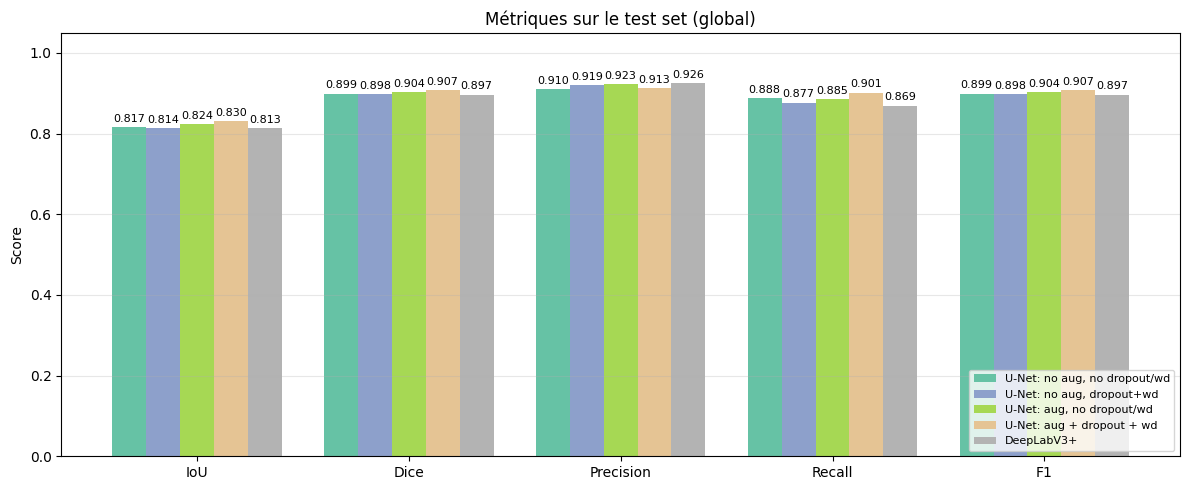

In [14]:
if results:
    df_global = df[df["Région"] == "Global"].copy()
    metric_names = ["IoU", "Dice", "Precision", "Recall", "F1"]

    x = np.arange(len(metric_names))
    n_models = len(df_global)
    width = 0.8 / max(n_models, 1)
    colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 1)))

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (_, row) in enumerate(df_global.iterrows()):
        vals = [row[m] for m in metric_names]
        offset = (i - n_models / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Modèle"], color=colors[i])
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=8,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Métriques sur le test set (global)")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

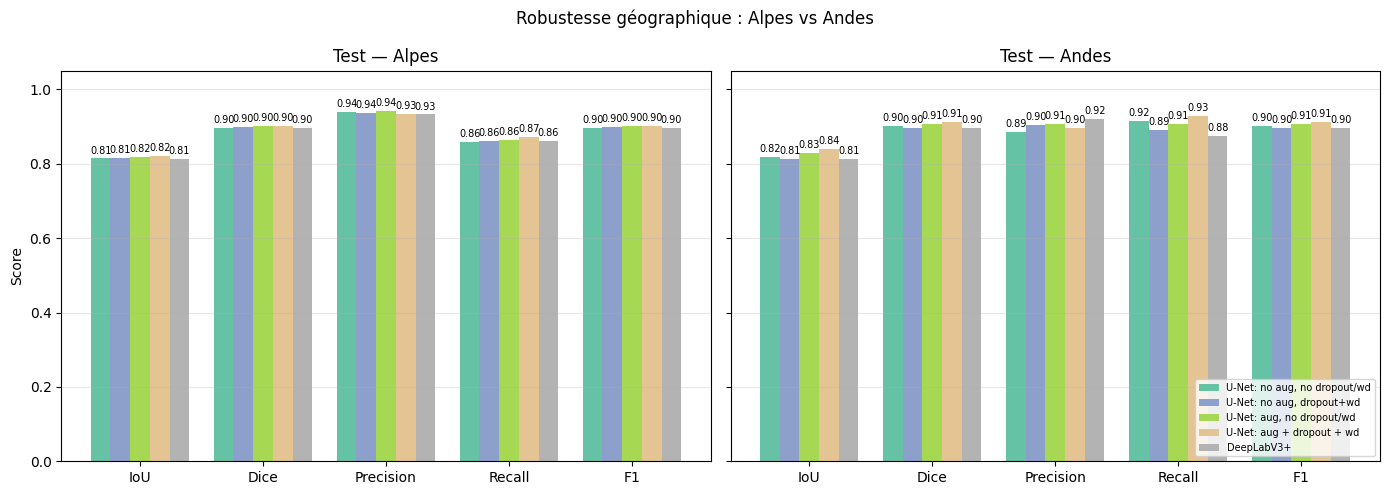

In [15]:
if results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    metric_names = ["IoU", "Dice", "Precision", "Recall", "F1"]
    x = np.arange(len(metric_names))

    for ax, region in zip(axes, ["Alpes", "Andes"]):
        df_r = df[df["Région"] == region]
        n = len(df_r)
        w = 0.8 / max(n, 1)
        c = plt.cm.Set2(np.linspace(0, 1, max(n, 1)))

        for i, (_, row) in enumerate(df_r.iterrows()):
            vals = [row[m] for m in metric_names]
            offset = (i - n / 2 + 0.5) * w
            bars = ax.bar(x + offset, vals, w, label=row["Modèle"], color=c[i])
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(metric_names)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Test — {region}")
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Score")
    axes[1].legend(loc="lower right", fontsize=7)
    plt.suptitle("Robustesse géographique : Alpes vs Andes", fontsize=12)
    plt.tight_layout()
    plt.show()

# Affichons quelques prédictions de notre meilleur modèle 

In [16]:
# Charger le meilleur modèle pour les visualisations
best_model = load_unet(CHECKPOINT_DIR / "best_unet.pt", dropout=0.0)

  Chargé : epoch=53, val IoU=0.7983814962839676


── Prédictions test : Alpes ──


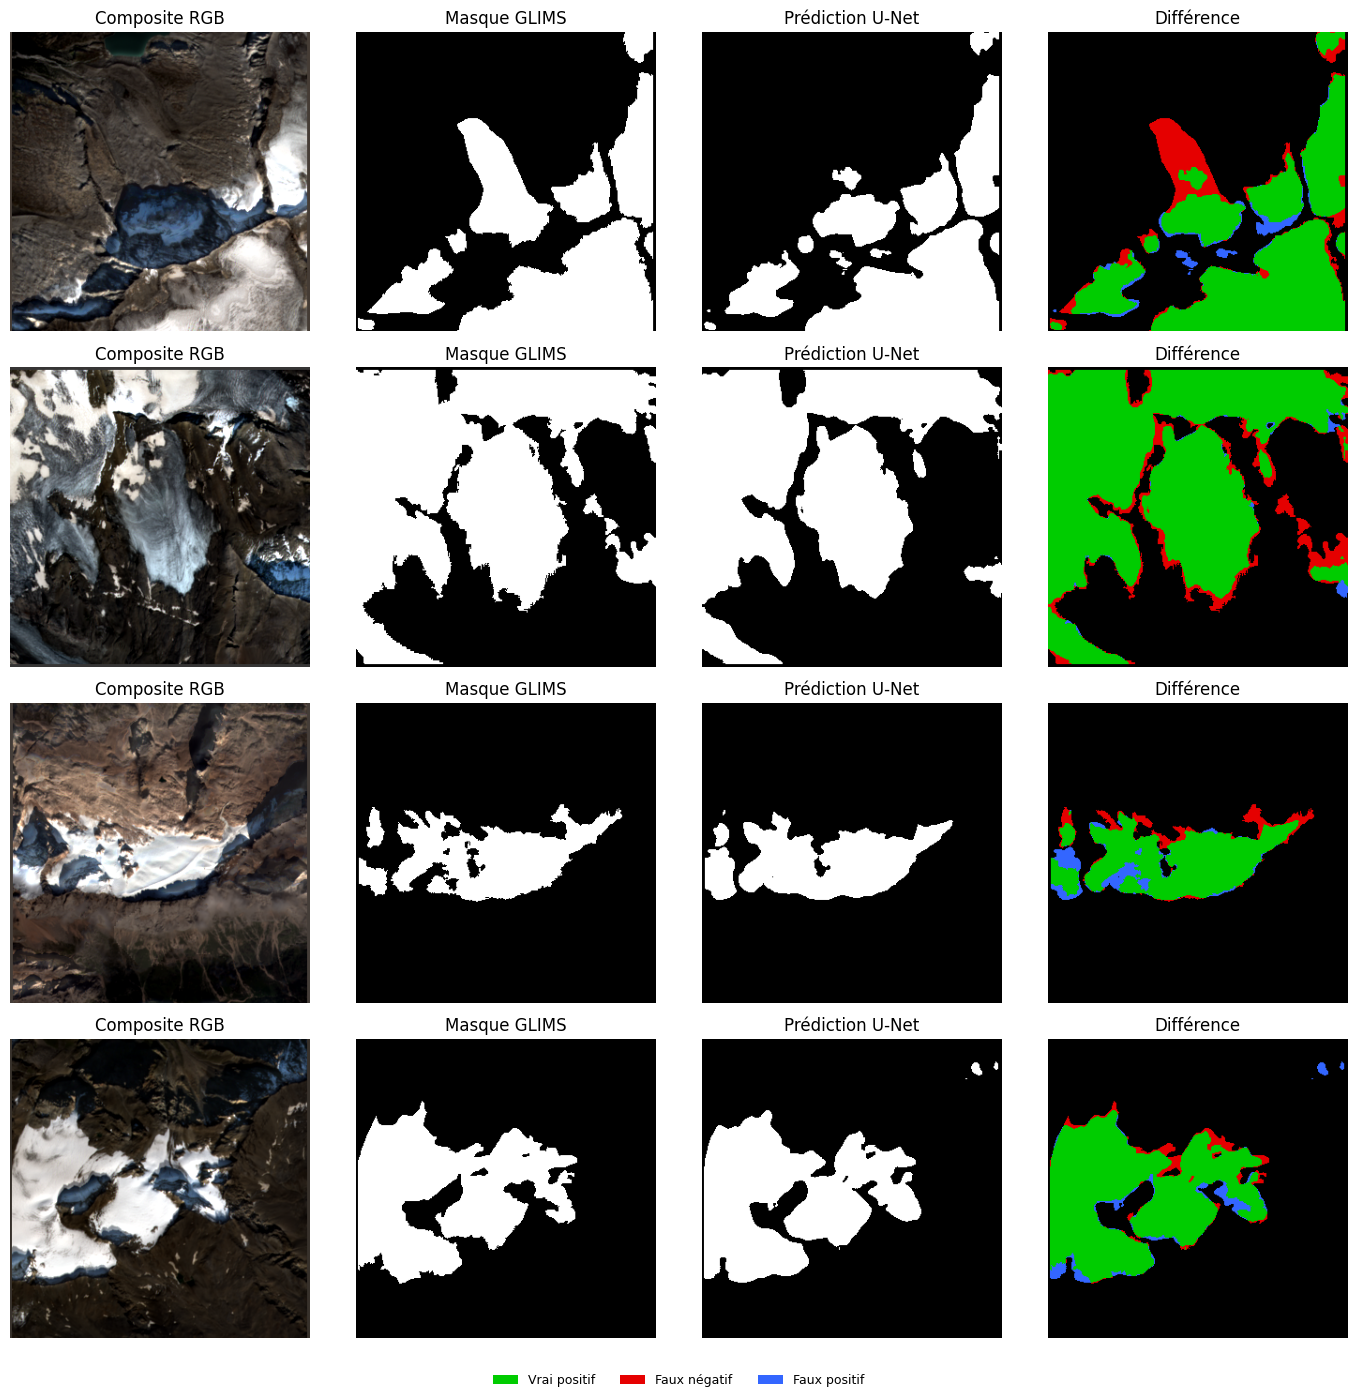

In [17]:
print("── Prédictions test : Alpes ──")
show_predictions(best_model, ds_test_alps, DEVICE, n=4)

── Prédictions test : Andes ──


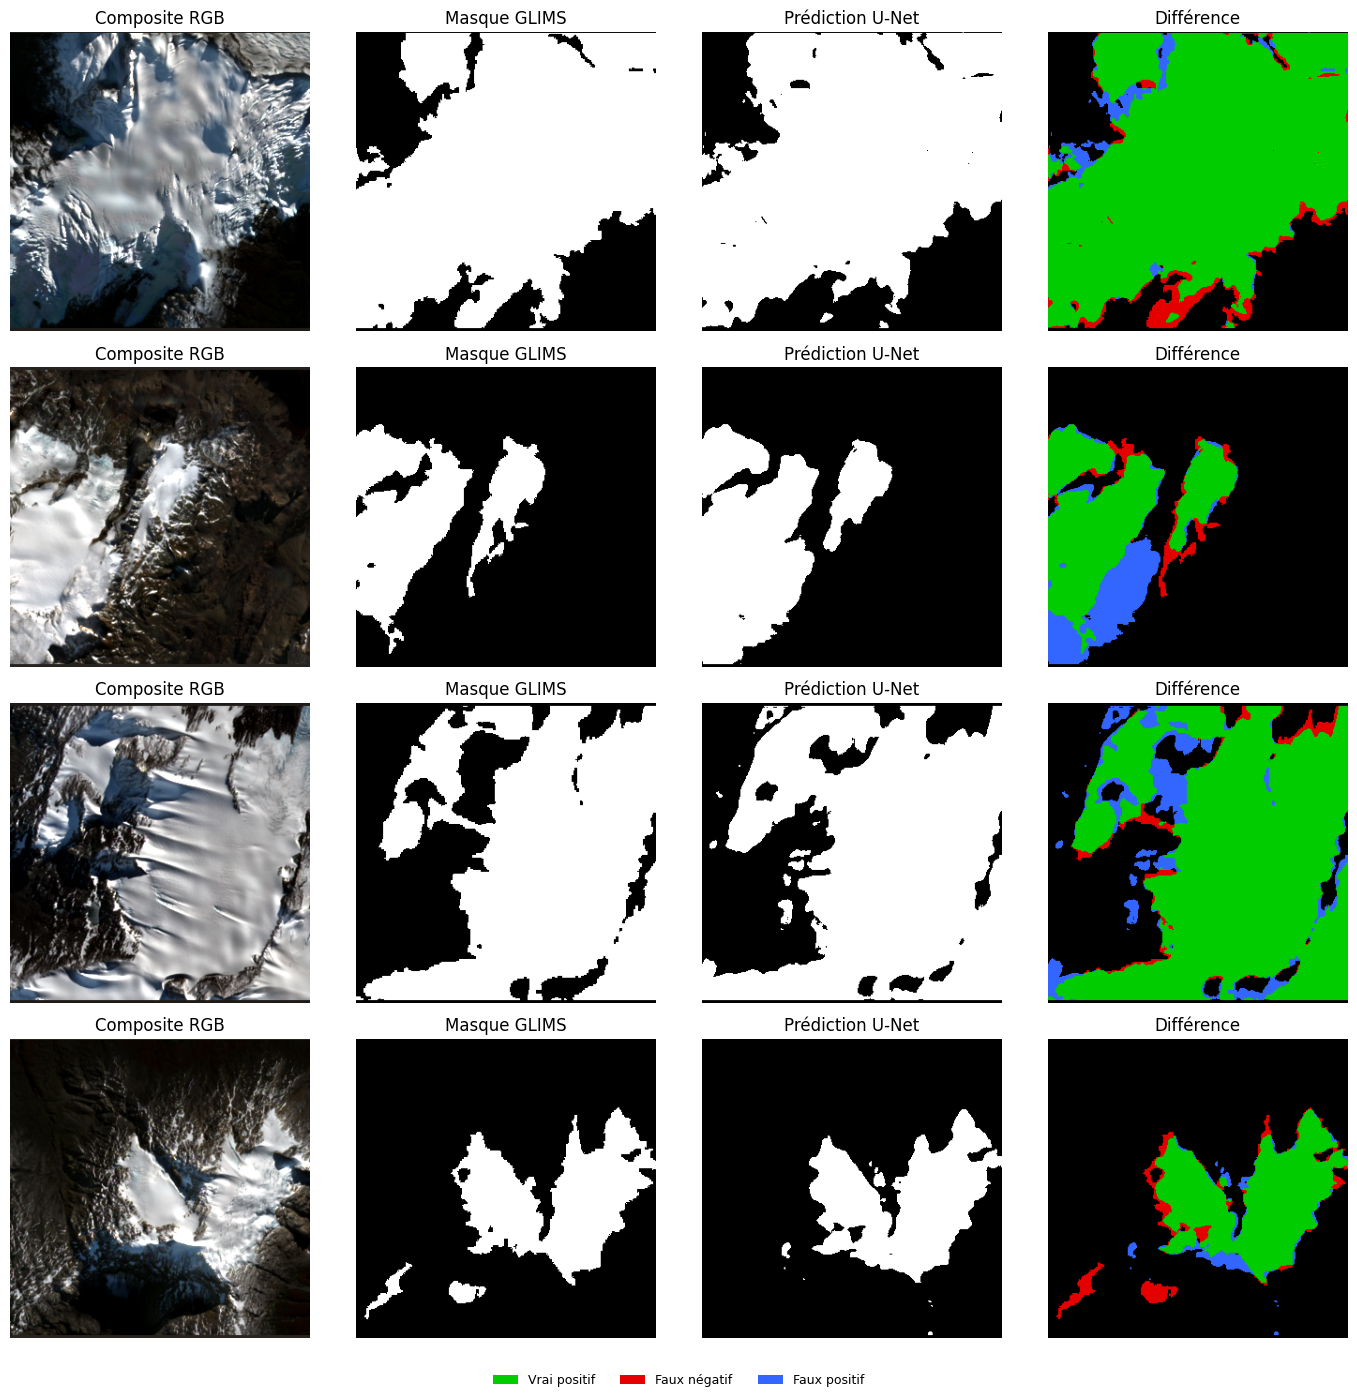

In [18]:
print("── Prédictions test : Andes ──")
show_predictions(best_model, ds_test_andes, DEVICE, n=4)